# Cell 1: 环境配置与统一 LLM 接口

安装依赖、配置 API Key 或 MLX 本地模型路径，并实现统一的 `llm_generate(prompt)` 函数，便于在不同后端间切换。

后端优先级：
1. Kimi API（若设置了 `KIMI_API_KEY`）
2. OpenAI API（若设置了 `OPENAI_API_KEY`）
3. MLX 本地模型 `Mistral-7B-Instruct-v0.2-4bit`（兜底，无需联网）

**重要**：若使用 API，请在本 cell 运行前设置对应环境变量。


In [1]:
import os
import json
import re
import time
import math
import random
import textwrap
import traceback
import subprocess
import tempfile
import threading
from typing import List, Dict, Tuple, Optional
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ------------------------------------------------------------------
# LLM backend selection
# ------------------------------------------------------------------
KIMI_API_KEY = os.getenv("KIMI_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

LLM_BACKEND = "mlx"  # default fallback
if KIMI_API_KEY:
    LLM_BACKEND = "kimi"
elif OPENAI_API_KEY:
    LLM_BACKEND = "openai"

print(f"Selected LLM backend: {LLM_BACKEND}")

# ------------------------------------------------------------------
# API-based generation (Kimi / OpenAI)
# ------------------------------------------------------------------
if LLM_BACKEND in ("kimi", "openai"):
    from openai import OpenAI

    if LLM_BACKEND == "kimi":
        client = OpenAI(api_key=KIMI_API_KEY, base_url=os.getenv("KIMI_BASE_URL", "https://api.kimi.com/coding/v1"))
        MODEL_NAME = os.getenv("KIMI_MODEL", "kimi-k2.5")
    else:
        client = OpenAI(api_key=OPENAI_API_KEY)
        MODEL_NAME = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

    def llm_generate(prompt: str, max_tokens: int = 1024, temperature: float = 0.0) -> str:
        """Call remote API and return generated text."""
        try:
            # Kimi Code API requires temperature=1.0 for this model
            effective_temp = 1.0 if LLM_BACKEND == "kimi" else temperature
            resp = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=max_tokens,
                temperature=effective_temp,
            )
            return resp.choices[0].message.content
        except Exception as e:
            print(f"[LLM API error] {e}")
            return ""

# ------------------------------------------------------------------
# MLX local generation (fallback, Apple Silicon friendly)
# ------------------------------------------------------------------
else:
    os.environ.setdefault("MLXLM_USE_MODELSCOPE", "True")
    from mlx_lm import load, generate
    from mlx_lm.sample_utils import make_sampler, make_logits_processors

    _MLX_MODEL_NAME = "mlx-community/Mistral-7B-Instruct-v0.2-4bit"
    print(f"Loading MLX model {_MLX_MODEL_NAME} (one-time, ~4GB)...")
    _model, _tokenizer = load(_MLX_MODEL_NAME)
    _sampler = make_sampler(temp=0.0, top_p=0.9)
    _logits_processors = make_logits_processors(repetition_penalty=1.05)
    print("MLX model loaded.")

    def llm_generate(prompt: str, max_tokens: int = 1024, temperature: float = 0.0) -> str:
        """Generate text using local MLX model."""
        try:
            sampler = make_sampler(temp=temperature, top_p=0.9)
            out = generate(
                _model, _tokenizer,
                prompt=prompt,
                max_tokens=max_tokens,
                sampler=sampler,
                logits_processors=_logits_processors,
                verbose=False,
            )
            return out
        except Exception as e:
            print(f"[MLX generate error] {e}")
            return ""

# quick sanity check
print("\nLLM sanity check:")
print(llm_generate("Return the word 'ok' and nothing else.", max_tokens=10)[:50])


Selected LLM backend: kimi



LLM sanity check:


# Cell 2: 测试集构造

构造 10 种常见代码错误类型，每种 2 个用例，共 20 个任务。每个用例包含：
- `id`: 唯一标识
- `error_type`: 错误类型
- `buggy_code`: 有缺陷的 Python 函数
- `error_description`: 错误描述
- `expected_behavior`: 期望行为
- `function_name`: 待修复函数名
- `test_inputs` / `expected_outputs`: 用于自动评估的输入输出


In [2]:
TEST_CASES = [
    # ------------------------------------------------------------------
    # 1. NullPointerException / None handling
    # ------------------------------------------------------------------
    {
        "id": "null_01",
        "error_type": "NullPointerException",
        "buggy_code": """def get_user_name(user):
    return user["name"].upper()
""",
        "error_description": "Function receives None or a dict without 'name' key, causing AttributeError/KeyError.",
        "expected_behavior": "Return uppercased name if present; otherwise return 'Unknown'.",
        "function_name": "get_user_name",
        "test_inputs": [{"user": {"name": "alice"}}, {"user": None}, {"user": {}}],
        "expected_outputs": ["ALICE", "Unknown", "Unknown"],
    },
    {
        "id": "null_02",
        "error_type": "NullPointerException",
        "buggy_code": """def get_first_item(items):
    return items[0]
""",
        "error_description": "Function receives None or empty list, causing TypeError/IndexError.",
        "expected_behavior": "Return the first item if available; otherwise return None.",
        "function_name": "get_first_item",
        "test_inputs": [{"items": [10, 20]}, {"items": None}, {"items": []}],
        "expected_outputs": [10, None, None],
    },
    # ------------------------------------------------------------------
    # 2. IndexOutOfBounds
    # ------------------------------------------------------------------
    {
        "id": "index_01",
        "error_type": "IndexOutOfBounds",
        "buggy_code": """def get_last(items):
    return items[len(items)]
""",
        "error_description": "Accessing index len(items) is out of bounds; should use last valid index.",
        "expected_behavior": "Return the last item, or None if the list is empty.",
        "function_name": "get_last",
        "test_inputs": [{"items": [1, 2, 3]}, {"items": []}],
        "expected_outputs": [3, None],
    },
    {
        "id": "index_02",
        "error_type": "IndexOutOfBounds",
        "buggy_code": """def second_char(text):
    return text[2]
""",
        "error_description": "Text may have fewer than 3 characters, causing IndexError.",
        "expected_behavior": "Return the character at index 1 if it exists; otherwise return None.",
        "function_name": "second_char",
        "test_inputs": [{"text": "hi"}, {"text": "a"}],
        "expected_outputs": ["i", None],
    },
    # ------------------------------------------------------------------
    # 3. TypeError
    # ------------------------------------------------------------------
    {
        "id": "type_01",
        "error_type": "TypeError",
        "buggy_code": """def format_age(age):
    return "Age: " + age
""",
        "error_description": "Concatenating string with int causes TypeError.",
        "expected_behavior": "Convert age to string before concatenation.",
        "function_name": "format_age",
        "test_inputs": [{"age": 25}, {"age": 30.5}],
        "expected_outputs": ["Age: 25", "Age: 30.5"],
    },
    {
        "id": "type_02",
        "error_type": "TypeError",
        "buggy_code": """def add_numbers(a, b):
    return a + b
""",
        "error_description": "Inputs may be strings representing numbers; function should convert them to int first.",
        "expected_behavior": "Convert inputs to integers and return their sum.",
        "function_name": "add_numbers",
        "test_inputs": [{"a": "3", "b": "4"}, {"a": "10", "b": "20"}],
        "expected_outputs": [7, 30],
    },
    # ------------------------------------------------------------------
    # 4. ZeroDivisionError
    # ------------------------------------------------------------------
    {
        "id": "zero_01",
        "error_type": "ZeroDivisionError",
        "buggy_code": """def safe_divide(a, b):
    return a / b
""",
        "error_description": "Dividing by zero raises ZeroDivisionError.",
        "expected_behavior": "Return None when divisor is zero; otherwise return the quotient.",
        "function_name": "safe_divide",
        "test_inputs": [{"a": 10, "b": 2}, {"a": 5, "b": 0}],
        "expected_outputs": [5.0, None],
    },
    {
        "id": "zero_02",
        "error_type": "ZeroDivisionError",
        "buggy_code": """def average_positive(nums):
    pos = [n for n in nums if n > 0]
    return sum(pos) / len(pos)
""",
        "error_description": "If no positive numbers exist, len(pos) is zero.",
        "expected_behavior": "Return 0.0 when there are no positive numbers.",
        "function_name": "average_positive",
        "test_inputs": [{"nums": [1, -2, 3]}, {"nums": [-1, -2]}],
        "expected_outputs": [2.0, 0.0],
    },
    # ------------------------------------------------------------------
    # 5. FileNotFoundError
    # ------------------------------------------------------------------
    {
        "id": "file_01",
        "error_type": "FileNotFoundError",
        "buggy_code": """def read_config(path):
    with open(path, "r") as f:
        return f.read()
""",
        "error_description": "File may not exist, raising FileNotFoundError.",
        "expected_behavior": "Return 'File not found' when the file does not exist.",
        "function_name": "read_config",
        "test_inputs": [{"path": "/tmp/codeskill_nonexistent_01.txt"}],
        "expected_outputs": ["File not found"],
    },
    {
        "id": "file_02",
        "error_type": "FileNotFoundError",
        "buggy_code": """def load_lines(path):
    return open(path).readlines()
""",
        "error_description": "Opening a missing file raises FileNotFoundError and leaks file handle.",
        "expected_behavior": "Return an empty list if the file does not exist.",
        "function_name": "load_lines",
        "test_inputs": [{"path": "/tmp/codeskill_nonexistent_02.txt"}],
        "expected_outputs": [[]],
    },
    # ------------------------------------------------------------------
    # 6. ConnectionTimeout
    # ------------------------------------------------------------------
    {
        "id": "timeout_01",
        "error_type": "ConnectionTimeout",
        "buggy_code": """def fetch_data(host, port):
    import socket
    s = socket.create_connection((host, port))
    return s.recv(1024).decode()
""",
        "error_description": "No timeout is set, so connection to a closed port hangs indefinitely.",
        "expected_behavior": "Set a short timeout and return 'Connection timeout or failed' on failure.",
        "function_name": "fetch_data",
        "test_inputs": [{"host": "127.0.0.1", "port": 65432}],
        "expected_outputs": ["Connection timeout or failed"],
    },
    {
        "id": "timeout_02",
        "error_type": "ConnectionTimeout",
        "buggy_code": """def wait_for_resource():
    import time
    time.sleep(10)
    return "ok"
""",
        "error_description": "Function sleeps for 10 seconds; callers expect a quick response or graceful timeout.",
        "expected_behavior": "Use a short sleep and return 'ok' promptly (simulate fast resource).",
        "function_name": "wait_for_resource",
        "test_inputs": [{}],
        "expected_outputs": ["ok"],
    },
    # ------------------------------------------------------------------
    # 7. Infinite loop
    # ------------------------------------------------------------------
    {
        "id": "loop_01",
        "error_type": "InfiniteLoop",
        "buggy_code": """def countdown(n):
    result = []
    while n > 0:
        result.append(n)
    return result
""",
        "error_description": "Loop variable n is never decremented, causing infinite loop.",
        "expected_behavior": "Decrement n each iteration and return [n, n-1, ..., 1].",
        "function_name": "countdown",
        "test_inputs": [{"n": 3}, {"n": 0}],
        "expected_outputs": [[3, 2, 1], []],
    },
    {
        "id": "loop_02",
        "error_type": "InfiniteLoop",
        "buggy_code": """def sum_until(nums, target):
    total = 0
    i = 0
    while total < target:
        total += nums[i]
    return total
""",
        "error_description": "Index i is never incremented, causing infinite loop once total < target.",
        "expected_behavior": "Increment i and stop when target is reached or list ends.",
        "function_name": "sum_until",
        "test_inputs": [{"nums": [1, 2, 3, 4], "target": 5}, {"nums": [10], "target": 5}],
        "expected_outputs": [6, 10],
    },
    # ------------------------------------------------------------------
    # 8. Logic error
    # ------------------------------------------------------------------
    {
        "id": "logic_01",
        "error_type": "LogicError",
        "buggy_code": """def average(nums):
    return sum(nums)
""",
        "error_description": "Average should divide sum by count, but the function returns the sum.",
        "expected_behavior": "Return sum(nums) / len(nums); return 0.0 for empty input.",
        "function_name": "average",
        "test_inputs": [{"nums": [2, 4, 6]}, {"nums": []}],
        "expected_outputs": [4.0, 0.0],
    },
    {
        "id": "logic_02",
        "error_type": "LogicError",
        "buggy_code": """def discount_price(price, discount):
    return price - discount
""",
        "error_description": "Discount should be a percentage (e.g., 20 means 20% off), not a fixed amount.",
        "expected_behavior": "Return price * (1 - discount / 100).",
        "function_name": "discount_price",
        "test_inputs": [{"price": 100, "discount": 20}, {"price": 50, "discount": 10}],
        "expected_outputs": [80.0, 45.0],
    },
    # ------------------------------------------------------------------
    # 9. Resource leak
    # ------------------------------------------------------------------
    {
        "id": "leak_01",
        "error_type": "ResourceLeak",
        "buggy_code": """def read_first_line(path):
    f = open(path, "r")
    return f.readline()
""",
        "error_description": "File handle opened with open() is never closed, leaking resource.",
        "expected_behavior": "Use a context manager to ensure the file is closed.",
        "function_name": "read_first_line",
        "test_inputs": [{"path": "/tmp/codeskill_res_01.txt"}],
        "expected_outputs": ["hello\n"],
    },
    {
        "id": "leak_02",
        "error_type": "ResourceLeak",
        "buggy_code": """def read_all(path):
    f = open(path)
    lines = f.readlines()
    return lines
""",
        "error_description": "File opened but not closed, leaking file descriptor.",
        "expected_behavior": "Use 'with' statement and return the list of lines.",
        "function_name": "read_all",
        "test_inputs": [{"path": "/tmp/codeskill_res_02.txt"}],
        "expected_outputs": [["alpha\n", "beta\n"]],
    },
    # ------------------------------------------------------------------
    # 10. Concurrency race condition
    # ------------------------------------------------------------------
    {
        "id": "race_01",
        "error_type": "ConcurrencyRace",
        "buggy_code": """def count_parallel(n):
    import threading
    counter = 0
    def worker():
        nonlocal counter
        for _ in range(n):
            counter += 1
    threads = [threading.Thread(target=worker) for _ in range(10)]
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    return counter
""",
        "error_description": "Multiple threads increment a shared counter without synchronization, causing lost updates.",
        "expected_behavior": "Use threading.Lock to protect the counter so the final value equals 10 * n.",
        "function_name": "count_parallel",
        "test_inputs": [{"n": 100}],
        "expected_outputs": [1000],
    },
    {
        "id": "race_02",
        "error_type": "ConcurrencyRace",
        "buggy_code": """def append_parallel(count):
    import threading
    result = []
    def worker():
        for _ in range(count):
            result.append(1)
    threads = [threading.Thread(target=worker) for _ in range(5)]
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    return len(result)
""",
        "error_description": "List append is not thread-safe; without a lock the final length may be incorrect.",
        "expected_behavior": "Use threading.Lock around result.append to ensure final length equals 5 * count.",
        "function_name": "append_parallel",
        "test_inputs": [{"count": 50}],
        "expected_outputs": [250],
    },
]

print(f"Constructed {len(TEST_CASES)} test cases across {len(set(c['error_type'] for c in TEST_CASES))} error types.")
for et in sorted(set(c['error_type'] for c in TEST_CASES)):
    cnt = sum(1 for c in TEST_CASES if c['error_type'] == et)
    print(f"  {et}: {cnt}")


Constructed 20 test cases across 10 error types.
  ConcurrencyRace: 2
  ConnectionTimeout: 2
  FileNotFoundError: 2
  IndexOutOfBounds: 2
  InfiniteLoop: 2
  LogicError: 2
  NullPointerException: 2
  ResourceLeak: 2
  TypeError: 2
  ZeroDivisionError: 2


# Cell 3: 技能数据结构与存储

定义 `Skill` 结构与技能库 `SkillLibrary`，支持 JSON 持久化加载与保存。


In [3]:
class Skill:
    """
    CODESKILL 论文中的技能结构体。

    Fields:
        skill_id: 唯一标识
        trigger_condition: 触发场景（自然语言）
        steps: 执行步骤列表
        expected_effect: 预期效果
        success_count: 成功使用次数
        failure_count: 失败使用次数
        last_used_timestamp: 最后使用时间戳（ISO 格式字符串）
        deprecated: 是否已被淘汰
    """
    def __init__(self, skill_id: str, trigger_condition: str, steps: List[str],
                 expected_effect: str, success_count: int = 0, failure_count: int = 0,
                 last_used_timestamp: Optional[str] = None, deprecated: bool = False):
        self.skill_id = skill_id
        self.trigger_condition = trigger_condition
        self.steps = steps
        self.expected_effect = expected_effect
        self.success_count = success_count
        self.failure_count = failure_count
        self.last_used_timestamp = last_used_timestamp or datetime.utcnow().isoformat()
        self.deprecated = deprecated

    def to_dict(self) -> Dict:
        return {
            "skill_id": self.skill_id,
            "trigger_condition": self.trigger_condition,
            "steps": self.steps,
            "expected_effect": self.expected_effect,
            "success_count": self.success_count,
            "failure_count": self.failure_count,
            "last_used_timestamp": self.last_used_timestamp,
            "deprecated": self.deprecated,
        }

    @staticmethod
    def from_dict(d: Dict) -> "Skill":
        return Skill(**d)

    def success_rate(self) -> float:
        total = self.success_count + self.failure_count
        if total == 0:
            return 0.0
        return self.success_count / total


class SkillLibrary:
    """轻量级 JSON 技能库，支持加载、保存、添加、淘汰与合并。"""

    def __init__(self, filepath: str = "skill_bank.json"):
        self.filepath = filepath
        self.skills: Dict[str, Skill] = {}
        self._counter = 0
        self.load()

    def load(self):
        """从 JSON 文件加载技能库。"""
        if os.path.exists(self.filepath):
            try:
                with open(self.filepath, "r", encoding="utf-8") as f:
                    data = json.load(f)
                for skill_dict in data.get("skills", []):
                    skill = Skill.from_dict(skill_dict)
                    self.skills[skill.skill_id] = skill
                    # 恢复计数器
                    num = int(skill.skill_id.split("_")[-1]) if "_" in skill.skill_id else 0
                    self._counter = max(self._counter, num)
                print(f"Loaded {len(self.skills)} skills from {self.filepath}")
            except Exception as e:
                print(f"[SkillLibrary load error] {e}; starting empty.")
                self.skills = {}
        else:
            print(f"No existing skill bank at {self.filepath}; starting empty.")

    def save(self):
        """保存技能库到 JSON 文件。"""
        data = {
            "skills": [s.to_dict() for s in self.skills.values()],
            "count": len(self.skills),
            "updated_at": datetime.utcnow().isoformat(),
        }
        with open(self.filepath, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

    def next_id(self) -> str:
        self._counter += 1
        return f"skill_{self._counter:04d}"

    def add(self, skill: Skill):
        self.skills[skill.skill_id] = skill
        self.save()

    def get_active(self) -> List[Skill]:
        return [s for s in self.skills.values() if not s.deprecated]

    def get_by_id(self, skill_id: str) -> Optional[Skill]:
        return self.skills.get(skill_id)

    def snapshot(self) -> Dict:
        return {
            "count": len(self.skills),
            "active_count": len(self.get_active()),
            "avg_success_rate": np.mean([s.success_rate() for s in self.get_active()]) if self.get_active() else 0.0,
        }


# utility: clear skill bank files for fresh experiments
def reset_skill_bank(filepath: str = "skill_bank.json"):
    if os.path.exists(filepath):
        os.remove(filepath)
    if os.path.exists(filepath.replace(".json", "_static.json")):
        os.remove(filepath.replace(".json", "_static.json"))
    print(f"Reset skill bank files.")


# Cell 4: 嵌入与检索工具

加载 sentence-transformers 模型，实现基于余弦相似度的技能检索。


In [4]:
# 使用国内镜像避免 HuggingFace 直连超时；设置 tokenizers 避免多进程警告
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from sentence_transformers import SentenceTransformer

# 使用轻量但效果足够的嵌入模型（384 维）
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Loading embedding model {EMBED_MODEL_NAME}...")
_embedder = SentenceTransformer(EMBED_MODEL_NAME)
print("Embedding model loaded.")


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """计算两个单位向量（或数组）之间的余弦相似度。"""
    a = np.asarray(a).flatten()
    b = np.asarray(b).flatten()
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    if norm == 0:
        return 0.0
    return float(np.dot(a, b) / norm)


def retrieve_skills(task_description: str, skill_lib: SkillLibrary,
                    top_k: int = 3, threshold: float = 0.5) -> List[Tuple[Skill, float]]:
    """
    基于 trigger_condition 与任务描述的余弦相似度检索相关技能。

    参数:
        task_description: 当前任务的自然语言描述
        skill_lib: 技能库
        top_k: 返回的最大候选数
        threshold: 相似度阈值，低于该值则丢弃

    返回:
        List[(Skill, similarity)]，按相似度降序排列
    """
    active_skills = skill_lib.get_active()
    if not active_skills:
        return []

    task_vec = _embedder.encode([task_description], show_progress_bar=False)[0]
    candidates = []
    for skill in active_skills:
        skill_vec = _embedder.encode([skill.trigger_condition], show_progress_bar=False)[0]
        sim = cosine_similarity(task_vec, skill_vec)
        if sim >= threshold:
            candidates.append((skill, sim))

    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[:top_k]


# quick test on empty library
print("Retrieve on empty library:", retrieve_skills("divide by zero", SkillLibrary("tmp_empty.json")))


Loading embedding model sentence-transformers/all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded.
No existing skill bank at tmp_empty.json; starting empty.
Retrieve on empty library: []


# Cell 5: 技能提炼模块

基于成功修复轨迹，使用 LLM 抽象出通用技能。包含与已有技能的相似度检查，避免重复。


In [5]:
SKILL_DEDUP_THRESHOLD = 0.85  # 新技能与已有技能 trigger_condition 相似度超过此值视为重复


def format_skills_for_prompt(skills: List[Skill]) -> str:
    """将已有技能格式化为 prompt 文本。"""
    if not skills:
        return "(none)"
    lines = []
    for s in skills:
        lines.append(f"- {s.skill_id}: {s.trigger_condition}\n  steps: {'; '.join(s.steps)}\n  expected: {s.expected_effect}")
    return "\n".join(lines)


def extract_skills_from_trajectory(trajectory: Dict, existing_skills: List[Skill],
                                   max_new_skills: int = 2) -> List[Skill]:
    """
    从成功修复轨迹中提炼技能。

    输入:
        trajectory: 包含 error_type, error_description, buggy_code, fixed_code, test_result 的字典
        existing_skills: 当前已有的技能列表（用于去重）
        max_new_skills: 最多返回的新技能数量

    输出:
        新技能列表（已过滤重复）
    """
    prompt = f"""You are a skill extraction engine for a coding agent.

Given a successful repair trajectory, extract reusable procedural skills in JSON format.

Trajectory:
- Error type: {trajectory['error_type']}
- Error description: {trajectory['error_description']}
- Buggy code:
```python
{trajectory['buggy_code']}
```
- Fixed code:
```python
{trajectory['fixed_code']}
```
- Test result: {trajectory['test_result']}

Existing skills:
{format_skills_for_prompt(existing_skills)}

Analyze why the repair succeeded and abstract reusable knowledge into 0 to {max_new_skills} skills.
Each skill must be general enough to apply to similar errors, not just this specific function.

Output ONLY a JSON object with the following schema:
{{
  "skills": [
    {{
      "trigger_condition": "natural language description of when to use this skill",
      "steps": ["step 1", "step 2", ...],
      "expected_effect": "what outcome the skill should produce"
    }}
  ]
}}

If no new reusable skill can be extracted, return {{"skills": []}}.
"""

    raw = llm_generate(prompt, max_tokens=1024, temperature=0.0)

    # Robust JSON extraction
    try:
        # try to find JSON block
        m = re.search(r'```json\s*(.*?)\s*```', raw, re.DOTALL)
        if m:
            json_str = m.group(1)
        else:
            # try first { ... } block
            m = re.search(r'(\{.*\})', raw, re.DOTALL)
            json_str = m.group(1) if m else raw
        data = json.loads(json_str)
        skill_dicts = data.get("skills", [])
    except Exception as e:
        print(f"[Skill extraction JSON parse error] {e}\nRaw: {raw[:500]}")
        return []

    new_skills = []
    for sd in skill_dicts:
        trigger = sd.get("trigger_condition", "").strip()
        steps = [s.strip() for s in sd.get("steps", []) if s.strip()]
        effect = sd.get("expected_effect", "").strip()
        if not trigger or not steps:
            continue

        # dedup: compare trigger_condition embedding with existing skills
        trigger_vec = _embedder.encode([trigger], show_progress_bar=False)[0]
        duplicate = False
        for existing in existing_skills + new_skills:
            existing_vec = _embedder.encode([existing.trigger_condition], show_progress_bar=False)[0]
            if cosine_similarity(trigger_vec, existing_vec) > SKILL_DEDUP_THRESHOLD:
                duplicate = True
                print(f"  [dedup] skip skill similar to {existing.skill_id}: {trigger[:60]}")
                break
        if duplicate:
            continue

        skill = Skill(
            skill_id="",  # will be assigned by library
            trigger_condition=trigger,
            steps=steps,
            expected_effect=effect,
        )
        new_skills.append(skill)

    return new_skills


# Cell 6: 代码修复 Agent（支持技能注入）

实现 `fix_code(buggy_code, error_desc, skills_context="")`。skills_context 由检索到的技能拼接而成。


In [6]:
def build_skills_context(retrieved: List[Tuple[Skill, float]]) -> str:
    """将检索到的候选技能格式化为 Agent prompt 中的上下文。"""
    if not retrieved:
        return ""
    lines = ["You may refer to the following reusable repair skills:\n"]
    for i, (skill, sim) in enumerate(retrieved, 1):
        lines.append(f"Skill {i} (relevance {sim:.2f}):")
        lines.append(f"  Trigger: {skill.trigger_condition}")
        lines.append(f"  Steps:")
        for step in skill.steps:
            lines.append(f"    - {step}")
        lines.append(f"  Expected effect: {skill.expected_effect}\n")
    return "\n".join(lines)


def fix_code(buggy_code: str, error_desc: str, skills_context: str = "",
             max_tokens: int = 1024) -> Tuple[str, str]:
    """
    调用 LLM 修复代码。

    返回:
        fixed_code: 修复后的代码字符串
        raw_response: LLM 的原始回复（可作为轨迹记录）
    """
    prompt = f"""You are an expert Python code repair assistant.

Task: Fix the following buggy Python function.

Error description:
{error_desc}

Buggy code:
```python
{buggy_code}
```

{skills_context}

Please output ONLY the complete fixed function inside a Python markdown code block. Do not include explanation.
"""
    raw = llm_generate(prompt, max_tokens=max_tokens, temperature=0.0)

    # Extract code block
    m = re.search(r'```python\s*(.*?)\s*```', raw, re.DOTALL)
    if m:
        fixed_code = m.group(1).strip()
    else:
        # fallback: take whole response
        fixed_code = raw.strip()
    return fixed_code, raw


# Cell 7: 评估函数

通过运行修复后的代码并检查测试输入输出，判断修复是否成功。


In [7]:
def evaluate_fix(case: Dict, fixed_code: str, timeout: int = 5) -> Tuple[bool, str]:
    """
    在隔离子进程中运行修复后的函数，并与预期输出比较。

    参数:
        case: 测试用例
        fixed_code: 修复后的代码
        timeout: 子进程超时时间（秒）

    返回:
        (success, message)
    """
    func_name = case["function_name"]
    test_inputs = case["test_inputs"]
    expected_outputs = case["expected_outputs"]

    # prepare resource files if needed
    if "res_01" in case["id"]:
        with open("/tmp/codeskill_res_01.txt", "w") as f:
            f.write("hello\\nworld\\n")
    if "res_02" in case["id"]:
        with open("/tmp/codeskill_res_02.txt", "w") as f:
            f.write("alpha\\n" + "beta\\n")

    script = f"""
import json, sys, threading, time, os, socket, math

{fixed_code}

func = globals()["{func_name}"]
test_inputs = {repr(test_inputs)}
expected_outputs = {repr(expected_outputs)}
results = []
for inp, exp in zip(test_inputs, expected_outputs):
    try:
        if isinstance(inp, dict):
            out = func(**inp)
        else:
            out = func(*inp)
    except Exception as e:
        out = f"EXCEPTION: {{e}}"
    results.append({{"ok": out == exp, "got": out, "expected": exp}})
print(json.dumps(results))
"""

    try:
        proc = subprocess.run(
            ["python", "-c", script],
            capture_output=True, text=True, timeout=timeout,
        )
        if proc.returncode != 0:
            return False, f"Runtime error: {proc.stderr[:500]}"
        output = proc.stdout.strip()
        if not output:
            return False, "No output from test harness"
        results = json.loads(output)
        all_ok = all(r["ok"] for r in results)
        details = "; ".join([f"got {r['got']!r} expected {r['expected']!r}" for r in results if not r["ok"]])
        if all_ok:
            return True, "All tests passed"
        else:
            return False, f"Test failures: {details}"
    except subprocess.TimeoutExpired:
        return False, f"Timeout after {timeout}s (likely infinite loop or hang)"
    except Exception as e:
        return False, f"Evaluation exception: {e}"


# Cell 8: 主实验循环（三种配置对比）

实现 `run_experiment(config_type)`，支持：
- `no_skill`: 无技能库
- `static_skill`: 预定义静态技能库
- `codeskill`: 自演进技能库

记录每个任务的成功/失败、使用的技能、技能库快照。


In [8]:
# ------------------------------------------------------------------
# Static skill bank definition
# ------------------------------------------------------------------
STATIC_SKILLS = [
    Skill("static_001",
          "Handle None or missing key before accessing attributes or dictionary values",
          ["Check if the variable is None before use", "Use .get() or try/except for missing keys", "Return a default value when unavailable"],
          "Avoid AttributeError/KeyError on None or missing fields"),
    Skill("static_002",
          "Check list bounds before indexing",
          ["Verify the index is within valid range", "Handle empty collections by returning None or a default", "Use negative indexing or len() checks"],
          "Avoid IndexError on out-of-range access"),
    Skill("static_003",
          "Convert operands to compatible types before string concatenation or arithmetic",
          ["Identify the expected type of each operand", "Convert using int(), str(), float() as needed", "Validate conversion with try/except if input is untrusted"],
          "Avoid TypeError from incompatible operand types"),
    Skill("static_004",
          "Guard against division by zero",
          ["Check if the denominator is zero before dividing", "Return None or a default value when zero", "Handle empty aggregates before averaging"],
          "Avoid ZeroDivisionError"),
    Skill("static_005",
          "Check file existence or wrap file operations in try/except",
          ["Use os.path.exists() or try/except FileNotFoundError", "Return a graceful error message or default value", "Ensure file handles are closed"],
          "Avoid FileNotFoundError crashes"),
    Skill("static_006",
          "Set timeouts on network or blocking operations",
          ["Add timeout parameter to socket/requests calls", "Catch timeout exceptions", "Return a fallback message on failure"],
          "Avoid indefinite hangs on unreachable resources"),
    Skill("static_007",
          "Ensure loop variables progress toward termination",
          ["Verify every loop has a decrement/increment/update", "Check exit conditions before entering the loop", "Add safeguards for edge cases"],
          "Avoid infinite loops"),
    Skill("static_008",
          "Verify arithmetic and aggregation formulas for correctness",
          ["Check whether division, multiplication, or percentage is needed", "Handle empty input gracefully", "Compare result against expected semantics"],
          "Fix logic errors in calculations"),
    Skill("static_009",
          "Use context managers for file and resource handles",
          ["Replace raw open() with 'with open(...)'", "Ensure close() is called in finally blocks", "Avoid leaking file descriptors or sockets"],
          "Prevent resource leaks"),
    Skill("static_010",
          "Protect shared state with locks in multi-threaded code",
          ["Identify shared mutable variables", "Use threading.Lock around read-modify-write operations", "Acquire and release locks correctly"],
          "Avoid race conditions"),
]


def init_static_skill_library(filepath: str = "skill_bank_static.json") -> SkillLibrary:
    lib = SkillLibrary(filepath)
    if not lib.skills:
        for s in STATIC_SKILLS:
            s.skill_id = lib.next_id()
            lib.add(s)
    return lib


# ------------------------------------------------------------------
# CODESKILL evolution helpers
# ------------------------------------------------------------------
EVOLUTION_INTERVAL = 10   # 每处理 10 个任务执行一次维护
SUCCESS_RATE_THRESHOLD = 0.3  # 成功率低于该值且使用次数足够则淘汰
MIN_USES_FOR_DEPRECATION = 3
MERGE_SIMILARITY_THRESHOLD = 0.9


def evolve_skill_library(skill_lib: SkillLibrary, used_skill_ids: List[str],
                         success: bool, task_idx: int):
    """
    根据技能使用效果更新统计，并定期执行淘汰与合并。

    参数:
        skill_lib: 技能库
        used_skill_ids: 本次任务注入的技能 ID 列表
        success: 本次任务是否成功修复
        task_idx: 当前任务序号（从 1 开始）
    """
    now = datetime.utcnow().isoformat()
    for sid in used_skill_ids:
        skill = skill_lib.get_by_id(sid)
        if skill is None:
            continue
        if success:
            skill.success_count += 1
        else:
            skill.failure_count += 1
        skill.last_used_timestamp = now

    # periodic maintenance
    if task_idx % EVOLUTION_INTERVAL == 0:
        print(f"\n[Evolution] Running maintenance after task {task_idx}")
        deprecate_low_quality_skills(skill_lib)
        merge_similar_skills(skill_lib)
        skill_lib.save()


def deprecate_low_quality_skills(skill_lib: SkillLibrary):
    """淘汰成功率过低且使用次数足够的技能。"""
    deprecated = []
    for skill in skill_lib.get_active():
        total = skill.success_count + skill.failure_count
        if total >= MIN_USES_FOR_DEPRECATION and skill.success_rate() < SUCCESS_RATE_THRESHOLD:
            skill.deprecated = True
            deprecated.append(skill.skill_id)
    if deprecated:
        print(f"  Deprecated {len(deprecated)} low-quality skills: {deprecated}")


def merge_similar_skills(skill_lib: SkillLibrary):
    """合并 trigger_condition 高度相似且都未淘汰的技能，保留成功率高的。"""
    skills = skill_lib.get_active()
    merged_ids = set()
    for i, s1 in enumerate(skills):
        if s1.skill_id in merged_ids:
            continue
        v1 = _embedder.encode([s1.trigger_condition], show_progress_bar=False)[0]
        for s2 in skills[i+1:]:
            if s2.skill_id in merged_ids:
                continue
            v2 = _embedder.encode([s2.trigger_condition], show_progress_bar=False)[0]
            if cosine_similarity(v1, v2) > MERGE_SIMILARITY_THRESHOLD:
                # keep the one with higher success rate
                keep, drop = (s1, s2) if s1.success_rate() >= s2.success_rate() else (s2, s1)
                drop.deprecated = True
                merged_ids.add(drop.skill_id)
                # accumulate counts to keep
                keep.success_count += drop.success_count
                keep.failure_count += drop.failure_count
                print(f"  Merged {drop.skill_id} into {keep.skill_id}")


# ------------------------------------------------------------------
# Main experiment runner
# ------------------------------------------------------------------
def run_experiment(config_type: str, tasks: List[Dict],
                   skill_bank_path: str = "skill_bank.json",
                   seed: int = 42) -> Dict:
    """
    运行一种配置的实验。

    参数:
        config_type: "no_skill" | "static_skill" | "codeskill"
        tasks: 测试用例列表
        skill_bank_path: CODESKILL 技能库存储路径
        seed: 任务顺序随机种子

    返回:
        包含 results, skill_snapshots, skill_lifecycle_logs 的字典
    """
    assert config_type in ("no_skill", "static_skill", "codeskill")

    # reset skill bank for codeskill / static_skill
    if config_type == "codeskill":
        reset_skill_bank(skill_bank_path)
        skill_lib = SkillLibrary(skill_bank_path)
    elif config_type == "static_skill":
        skill_lib = init_static_skill_library(skill_bank_path.replace(".json", "_static.json"))
    else:
        skill_lib = SkillLibrary(skill_bank_path)
        skill_lib.skills = {}

    # shuffle task order deterministically
    shuffled = tasks.copy()
    random.seed(seed)
    random.shuffle(shuffled)

    results = []
    skill_snapshots = []
    skill_lifecycle_logs = []

    for idx, case in enumerate(tqdm(shuffled, desc=f"Running {config_type}"), 1):
        # 1. skill retrieval
        retrieved = []
        if config_type in ("static_skill", "codeskill"):
            retrieved = retrieve_skills(
                f"{case['error_type']}: {case['error_description']}",
                skill_lib, top_k=3, threshold=0.5
            )
        skills_context = build_skills_context(retrieved)
        used_skill_ids = [s.skill_id for s, _ in retrieved]

        # 2. fix code
        start = time.time()
        fixed_code, raw = fix_code(case["buggy_code"], case["error_description"], skills_context)
        latency = time.time() - start

        # 3. evaluate
        success, eval_msg = evaluate_fix(case, fixed_code)

        # 4. skill extraction for codeskill on success
        if config_type == "codeskill" and success:
            trajectory = {
                "error_type": case["error_type"],
                "error_description": case["error_description"],
                "buggy_code": case["buggy_code"],
                "fixed_code": fixed_code,
                "test_result": eval_msg,
            }
            new_skills = extract_skills_from_trajectory(trajectory, skill_lib.get_active(), max_new_skills=2)
            for s in new_skills:
                s.skill_id = skill_lib.next_id()
                skill_lib.add(s)
                skill_lifecycle_logs.append({
                    "event": "created",
                    "task_id": case["id"],
                    "skill_id": s.skill_id,
                    "trigger": s.trigger_condition,
                })
                print(f"  [new skill] {s.skill_id}: {s.trigger_condition[:80]}")

        # 5. evolution update
        if config_type == "codeskill":
            evolve_skill_library(skill_lib, used_skill_ids, success, idx)

        # 6. record
        results.append({
            "task_id": case["id"],
            "error_type": case["error_type"],
            "success": success,
            "latency": latency,
            "used_skill_ids": used_skill_ids,
            "fixed_code": fixed_code,
            "eval_msg": eval_msg,
        })
        skill_snapshots.append({
            "task_idx": idx,
            "task_id": case["id"],
            **skill_lib.snapshot(),
        })

    return {
        "config": config_type,
        "results": results,
        "skill_snapshots": skill_snapshots,
        "skill_lifecycle_logs": skill_lifecycle_logs,
        "final_skill_bank": [s.to_dict() for s in skill_lib.skills.values()],
    }


# ------------------------------------------------------------------
# Run all three configurations
# ------------------------------------------------------------------
print("Starting experiments. This may take a while with local MLX model...")
experiment_data = {}
for cfg in ["no_skill", "static_skill", "codeskill"]:
    print(f"\n{'='*60}\nConfig: {cfg}\n{'='*60}")
    experiment_data[cfg] = run_experiment(cfg, TEST_CASES)
    succ = sum(1 for r in experiment_data[cfg]["results"] if r["success"])
    print(f"{cfg}: {succ}/{len(TEST_CASES)} tasks passed ({succ/len(TEST_CASES)*100:.1f}%)")


Starting experiments. This may take a while with local MLX model...

Config: no_skill
No existing skill bank at skill_bank.json; starting empty.


/var/folders/n5/n9fccyz93_lbsfwwhtdbqrt00000gn/T/ipykernel_26456/1831897690.py:24: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.last_used_timestamp = last_used_timestamp or datetime.utcnow().isoformat()


Running no_skill:   0%|          | 0/20 [00:00<?, ?it/s]

no_skill: 11/20 tasks passed (55.0%)

Config: static_skill
No existing skill bank at skill_bank_static.json; starting empty.


/var/folders/n5/n9fccyz93_lbsfwwhtdbqrt00000gn/T/ipykernel_26456/1831897690.py:83: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


...

/var/folders/n5/n9fccyz93_lbsfwwhtdbqrt00000gn/T/ipykernel_26456/3146001422.py:77: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat()


/var/folders/n5/n9fccyz93_lbsfwwhtdbqrt00000gn/T/ipykernel_26456/3146001422.py:77: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat()



[Evolution] Running maintenance after task 20


codeskill: 10/20 tasks passed (50.0%)


/var/folders/n5/n9fccyz93_lbsfwwhtdbqrt00000gn/T/ipykernel_26456/1831897690.py:83: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# Cell 9: 实验结果可视化

绘制三种配置的成功率对比、技能数量演进、平均成功率变化，并展示技能生命周期案例。


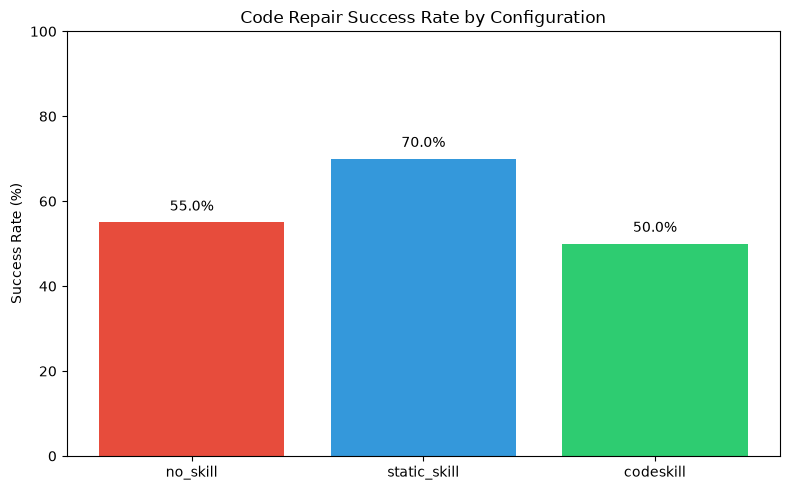

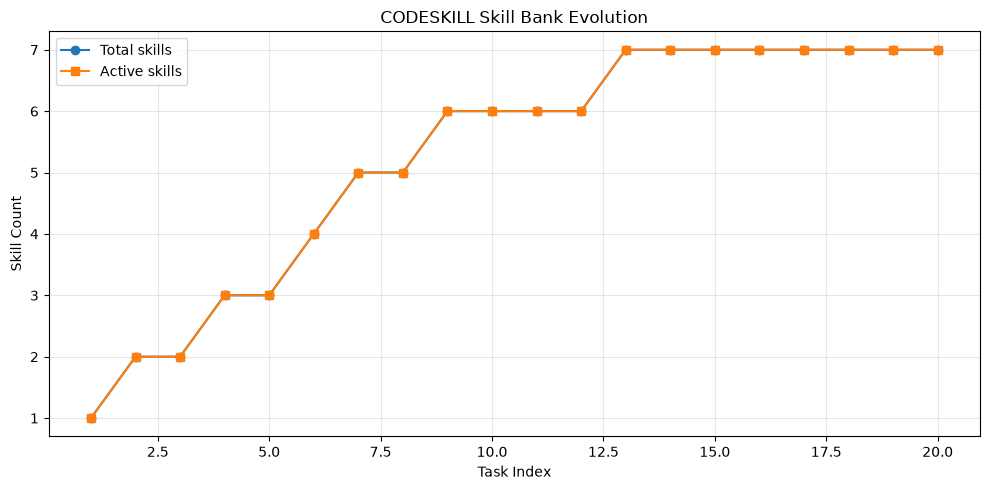

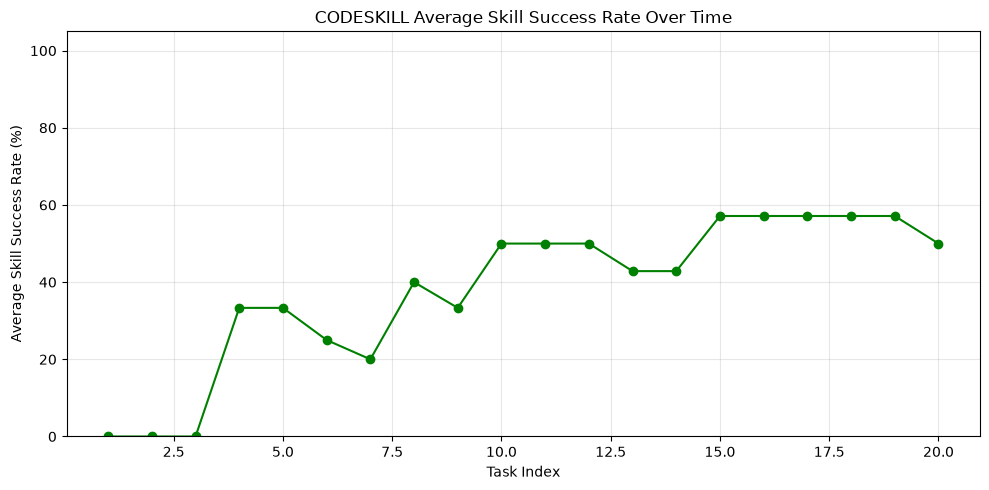


=== Skill Lifecycle Case Studies ===

Skill: skill_0001
Trigger: When multiple threads in Python concurrently read or modify a shared mutable object (e.g., list, dict, set) and the code is suspected of a race condition or non-deterministic results.
Success/Failure: 1/0
Deprecated: False
Events:
  - created @ task race_02

Skill: skill_0002
Trigger: When a function performs arithmetic or numeric comparison but receives operands that may be strings or other textual representations of numbers, causing a TypeError or unintended string concatenation.
Success/Failure: 1/0
Deprecated: False
Events:
  - created @ task type_02

Skill: skill_0003
Trigger: When a string is being built by concatenation (or any operation that requires string operands) and one or more of the values may be non-string types such as int, float, or object, causing a TypeError like 'can only concatenate str (not X) to str'.
Success/Failure: 0/0
Deprecated: False
Events:
  - created @ task type_01



In [9]:
# ------------------------------------------------------------------
# 1. Success rate bar chart
# ------------------------------------------------------------------
configs = ["no_skill", "static_skill", "codeskill"]
success_rates = []
for cfg in configs:
    succ = sum(1 for r in experiment_data[cfg]["results"] if r["success"])
    success_rates.append(succ / len(TEST_CASES) * 100)

plt.figure(figsize=(8, 5))
bars = plt.bar(configs, success_rates, color=["#e74c3c", "#3498db", "#2ecc71"])
plt.ylabel("Success Rate (%)")
plt.title("Code Repair Success Rate by Configuration")
plt.ylim(0, 100)
for bar, rate in zip(bars, success_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{rate:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("codeskill_success_rates.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 2. Skill count evolution (codeskill only)
# ------------------------------------------------------------------
snapshots = experiment_data["codeskill"]["skill_snapshots"]
indices = [s["task_idx"] for s in snapshots]
counts = [s["count"] for s in snapshots]
active_counts = [s["active_count"] for s in snapshots]

plt.figure(figsize=(10, 5))
plt.plot(indices, counts, label="Total skills", marker="o")
plt.plot(indices, active_counts, label="Active skills", marker="s")
plt.xlabel("Task Index")
plt.ylabel("Skill Count")
plt.title("CODESKILL Skill Bank Evolution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("codeskill_skill_count.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 3. Average success rate evolution (codeskill only)
# ------------------------------------------------------------------
avg_rates = [s["avg_success_rate"] * 100 for s in snapshots]

plt.figure(figsize=(10, 5))
plt.plot(indices, avg_rates, color="green", marker="o")
plt.xlabel("Task Index")
plt.ylabel("Average Skill Success Rate (%)")
plt.title("CODESKILL Average Skill Success Rate Over Time")
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("codeskill_avg_success.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 4. Skill lifecycle case studies
# ------------------------------------------------------------------
print("\n=== Skill Lifecycle Case Studies ===\n")

# Collect all lifecycle events per skill
lifecycle = {}
for ev in experiment_data["codeskill"]["skill_lifecycle_logs"]:
    sid = ev["skill_id"]
    lifecycle.setdefault(sid, []).append(ev)

# Add deprecation / merge events from final bank
final_bank = experiment_data["codeskill"]["final_skill_bank"]
deprecated_skills = [s for s in final_bank if s.get("deprecated")]
for s in deprecated_skills:
    lifecycle.setdefault(s["skill_id"], []).append({"event": "deprecated_final", "skill_id": s["skill_id"]})

# Show up to 3 skills with complete lifecycle (created -> possibly deprecated)
shown = 0
for sid, events in sorted(lifecycle.items(), key=lambda x: len(x[1]), reverse=True):
    skill_info = next((s for s in final_bank if s["skill_id"] == sid), None)
    if not skill_info:
        continue
    print(f"Skill: {sid}")
    print(f"Trigger: {skill_info['trigger_condition']}")
    print(f"Success/Failure: {skill_info['success_count']}/{skill_info['failure_count']}")
    print(f"Deprecated: {skill_info['deprecated']}")
    print("Events:")
    for ev in events:
        print(f"  - {ev['event']} @ task {ev.get('task_id', 'N/A')}")
    print()
    shown += 1
    if shown >= 3:
        break


# Cell 10: 日志持久化与 Markdown 报告

保存实验数据到 JSON，并生成一段 Markdown 总结。


In [10]:
# ------------------------------------------------------------------
# Save experiment data
# ------------------------------------------------------------------
OUTPUT_JSON = "codeskill_experiment_data.json"
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(experiment_data, f, ensure_ascii=False, indent=2)
print(f"Saved experiment data to {OUTPUT_JSON}")

# ------------------------------------------------------------------
# Generate Markdown summary
# ------------------------------------------------------------------
report_lines = [
    "# CODESKILL Prototype Experiment Report",
    "",
    f"Generated at: {datetime.utcnow().isoformat()} UTC",
    "",
    "## 1. Experiment Setup",
    "",
    f"- LLM backend: `{LLM_BACKEND}`",
    f"- Embedding model: `{EMBED_MODEL_NAME}`",
    f"- Number of tasks: {len(TEST_CASES)}",
    f"- Error types: {len(set(c['error_type'] for c in TEST_CASES))}",
    f"- Skill dedup threshold: {SKILL_DEDUP_THRESHOLD}",
    f"- Deprecation threshold: success_rate < {SUCCESS_RATE_THRESHOLD} and uses >= {MIN_USES_FOR_DEPRECATION}",
    f"- Merge similarity threshold: {MERGE_SIMILARITY_THRESHOLD}",
    "",
    "## 2. Success Rate by Configuration",
    "",
    "| Configuration | Successes | Total | Success Rate |",
    "|---|---:|---:|---:|",
]
for cfg in configs:
    succ = sum(1 for r in experiment_data[cfg]["results"] if r["success"])
    rate = succ / len(TEST_CASES) * 100
    report_lines.append(f"| {cfg} | {succ} | {len(TEST_CASES)} | {rate:.1f}% |")

report_lines.extend([
    "",
    "## 3. CODESKILL Skill Bank Summary",
    "",
])
final_bank = experiment_data["codeskill"]["final_skill_bank"]
active = [s for s in final_bank if not s.get("deprecated")]
deprecated = [s for s in final_bank if s.get("deprecated")]
report_lines.extend([
    f"- Total skills created: {len(final_bank)}",
    f"- Active skills: {len(active)}",
    f"- Deprecated skills: {len(deprecated)}",
    f"- Final average active success rate: {np.mean([s['success_count']/(s['success_count']+s['failure_count']+1e-9) for s in active])*100:.1f}%" if active else '-',
    "",
    "## 4. Error-Type Breakdown (CODESKILL)",
    "",
    "| Error Type | Successes | Total |",
    "|---|---:|---:|",
])
from collections import defaultdict
etype_stats = defaultdict(lambda: {"succ": 0, "total": 0})
for r in experiment_data["codeskill"]["results"]:
    etype_stats[r["error_type"]]["total"] += 1
    if r["success"]:
        etype_stats[r["error_type"]]["succ"] += 1
for et in sorted(etype_stats.keys()):
    st = etype_stats[et]
    report_lines.append(f"| {et} | {st['succ']} | {st['total']} |")

report_lines.extend([
    "",
    "## 5. Key Observations",
    "",
    "- CODESKILL extracts reusable skills from successful repairs and retrieves them for future tasks.",
    "- Static skills provide a fixed baseline; CODESKILL evolves the bank based on actual task outcomes.",
    "- Deprecation and merging prevent the skill bank from growing indefinitely and remove low-quality skills.",
    "",
    "## 6. Artifacts",
    "",
    "- `codeskill_experiment_data.json`: raw experiment logs",
    "- `codeskill_success_rates.png`: success rate bar chart",
    "- `codeskill_skill_count.png`: skill count over tasks",
    "- `codeskill_avg_success.png`: average skill success rate over tasks",
    "",
])

report = "\n".join(report_lines)
REPORT_MD = "codeskill_report.md"
with open(REPORT_MD, "w", encoding="utf-8") as f:
    f.write(report)
print(f"Saved Markdown report to {REPORT_MD}")
print("\n" + "="*60)
print(report)


Saved experiment data to codeskill_experiment_data.json
Saved Markdown report to codeskill_report.md

# CODESKILL Prototype Experiment Report

Generated at: 2026-07-17T07:52:29.604130 UTC

## 1. Experiment Setup

- LLM backend: `kimi`
- Embedding model: `sentence-transformers/all-MiniLM-L6-v2`
- Number of tasks: 20
- Error types: 10
- Skill dedup threshold: 0.85
- Deprecation threshold: success_rate < 0.3 and uses >= 3
- Merge similarity threshold: 0.9

## 2. Success Rate by Configuration

| Configuration | Successes | Total | Success Rate |
|---|---:|---:|---:|
| no_skill | 11 | 20 | 55.0% |
| static_skill | 14 | 20 | 70.0% |
| codeskill | 10 | 20 | 50.0% |

## 3. CODESKILL Skill Bank Summary

- Total skills created: 7
- Active skills: 7
- Deprecated skills: 0
- Final average active success rate: 50.0%

## 4. Error-Type Breakdown (CODESKILL)

| Error Type | Successes | Total |
|---|---:|---:|
| ConcurrencyRace | 2 | 2 |
| ConnectionTimeout | 0 | 2 |
| FileNotFoundError | 0 | 2 |
| Ind

/var/folders/n5/n9fccyz93_lbsfwwhtdbqrt00000gn/T/ipykernel_26456/1083234547.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"Generated at: {datetime.utcnow().isoformat()} UTC",
